In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('figures', exist_ok=True)

In [4]:
spy = yf.download('SPY', start='2019-01-01', end='2025-01-01')
spy.columns = spy.columns.get_level_values(0)  # flatten multi-level columns
spy['Return'] = 100 * spy['Close'].pct_change()
spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


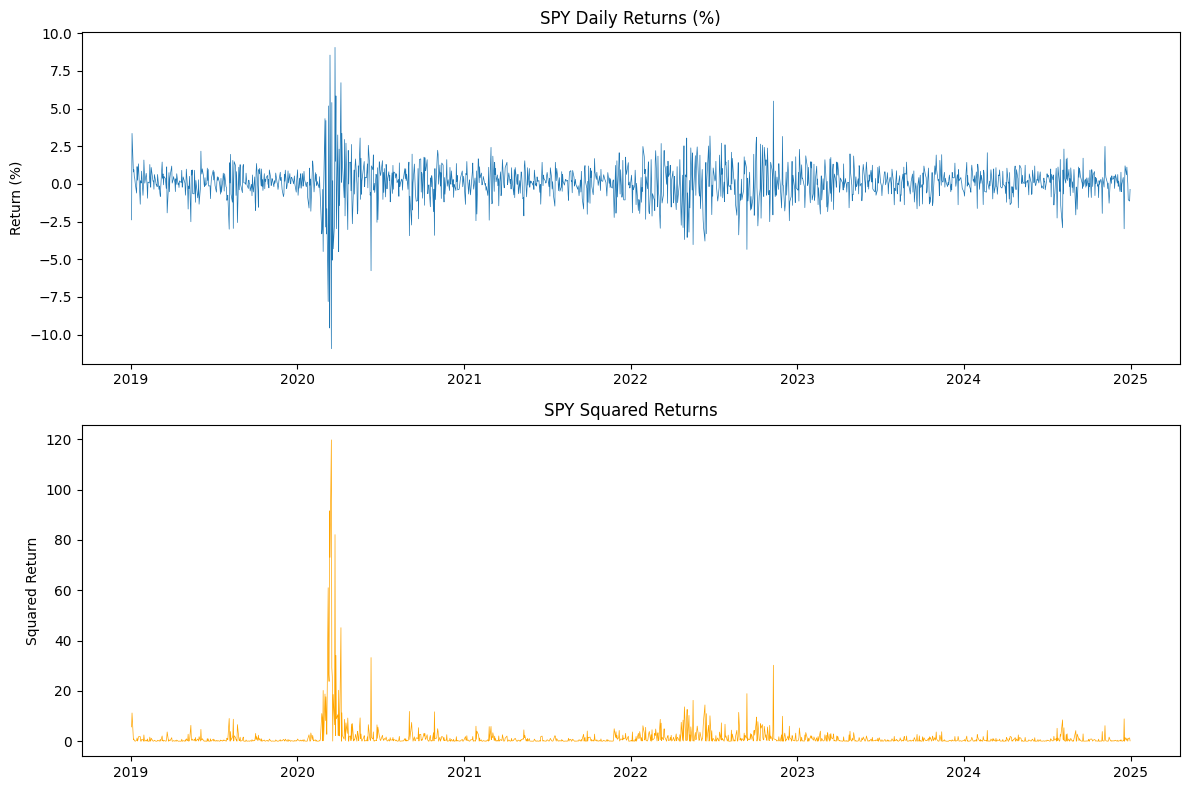

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(spy.index, spy['Return'], linewidth=0.5)
axes[0].set_title('SPY Daily Returns (%)')
axes[0].set_ylabel('Return (%)')

axes[1].plot(spy.index, spy['Return']**2, linewidth=0.5, color='orange')
axes[1].set_title('SPY Squared Returns')
axes[1].set_ylabel('Squared Return')
plt.tight_layout()
plt.savefig('figures/returns_and_squared.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
model = arch_model(spy['Return'], vol='Garch', p=1, q=1, mean='Constant', dist='normal')
result = model.fit(disp='off')
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2098.99
Distribution:                  Normal   AIC:                           4205.97
Method:            Maximum Likelihood   BIC:                           4227.25
                                        No. Observations:                 1509
Date:                Sun, Mar 08 2026   Df Residuals:                     1508
Time:                        16:03:35   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1056  2.126e-02      4.967  6.809e-07 [6.393e-0

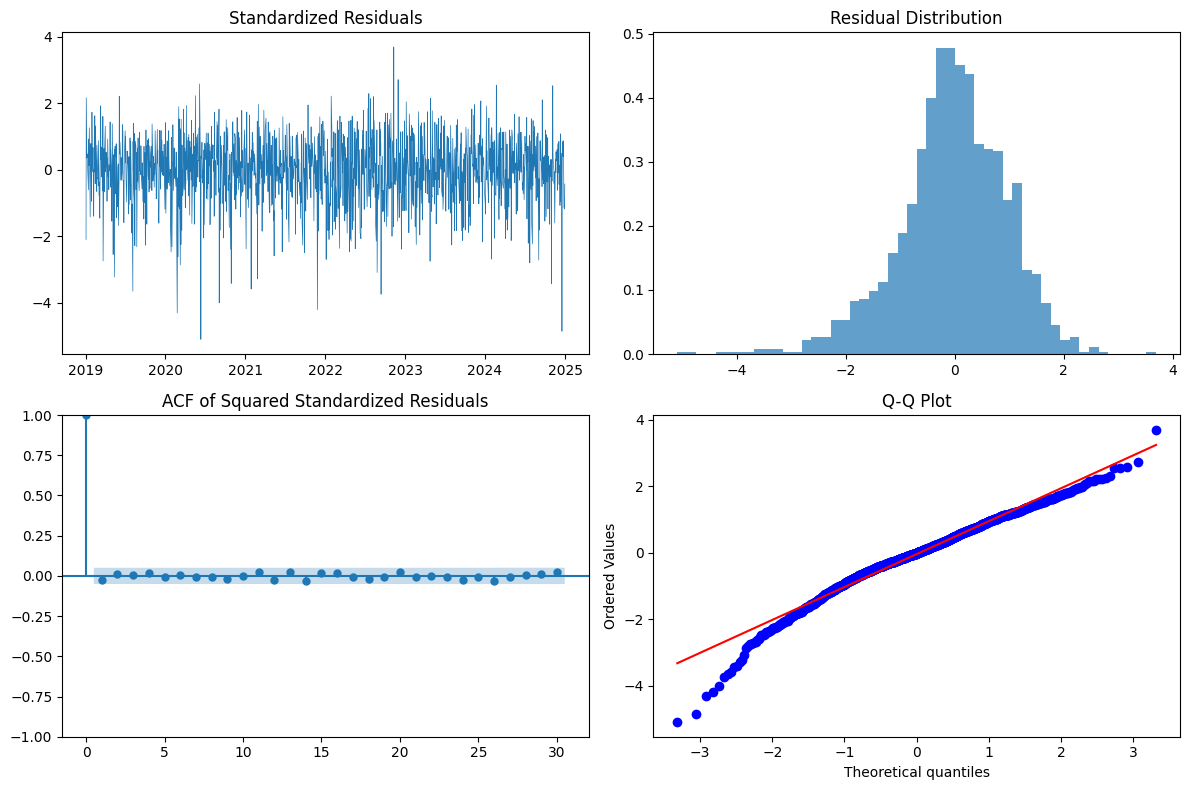

In [9]:
std_resid = result.resid / result.conditional_volatility

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(std_resid, linewidth=0.5)
axes[0, 0].set_title('Standardized Residuals')

axes[0, 1].hist(std_resid, bins=50, density=True, alpha=0.7)
axes[0, 1].set_title('Residual Distribution')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=30, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Squared Standardized Residuals')

from scipy.stats import probplot
probplot(std_resid, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('figures/garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Ljung-Box on squared standardized residuals
lb_test = acorr_ljungbox(std_resid**2, lags=[10, 20, 30], return_df=True)
print("Ljung-Box test on squared standardized residuals:")
print(lb_test)
print()

# Jarque-Bera on standardized residuals
jb_result = jarque_bera(std_resid)
print(f"Jarque-Bera: stat={jb_result.statistic:.2f}, p={jb_result.pvalue:.4f}")
print(f"Skewness: {std_resid.skew():.4f}, Kurtosis: {std_resid.kurtosis() + 3:.4f}")


Ljung-Box test on squared standardized residuals:
      lb_stat  lb_pvalue
10   2.615908   0.989077
20   9.575738   0.975229
30  13.838790   0.994832

Jarque-Bera: stat=238.52, p=0.0000
Skewness: -0.6061, Kurtosis: 4.5346


## Key Findings

- GARCH(1,1) parameters: omega=___, alpha=___, beta=___
- Persistence (alpha + beta): ___
- Ljung-Box on squared standardized residuals: p=___ (compare to ARIMA squared residuals)
- Jarque-Bera: p=___, skewness=___, kurtosis=___
- Conditional volatility captures COVID spike and subsequent regimes
- Remaining fat tails and negative skewness motivate asymmetric models (EGARCH, GJR-GARCH)